# Final Project ImmuniVision: Predictive Approach for Global Immunization Gaps

## 1. Business Problem Definition and Dataset Overview

### 1.1 Business Problem Definition

Low vaccination rates in certain regions continue to pose significant public health risks, increasing the likelihood of preventable disease outbreaks and placing immense strain on healthcare systems. These gaps are driven by socio-economic disparities, logistical challenges, and misinformation, creating persistent barriers to achieving adequate immunization coverage.

To address this, there is a critical need for a data-driven approach that leverages predictive modeling and analytics to identify high-risk regions with potential immunization shortfalls. By integrating socio-economic, geographic, and historical vaccination data, this analysis will provide actionable insights to:

- **Prioritize regions** requiring immediate intervention to prevent disease outbreaks.  
- **Optimize resource allocation** to maximize the effectiveness of vaccination campaigns.  
- **Tailor immunization strategies** to address region-specific needs and challenges.  

These insights will empower health organizations like UNICEF and WHO to implement targeted interventions, close immunization gaps, and strengthen healthcare system resilience. Ultimately, this approach aims to protect vulnerable populations from preventable diseases, enhance global health equity, and build a foundation for sustainable public health outcomes.

### 1.2 Dataset Overview

**Dataset Link** 
 https://data.unicef.org/resources/dataset/immunization/

**Summary of Dataset Attributes**

The dataset includes the following key attributes:

- **ISO3**: Categorical feature representing country codes (e.g., `AFG`, `USA`).
- **surveyNameEnglish**: Categorical feature containing the English name of the survey.
- **surveyNameProduction**: Categorical feature for the production name of the survey.
- **collectBegin**: Categorical feature representing the start of data collection (Year-Month).
- **collectEnd**: Categorical feature representing the end of data collection (Year-Month).
- **cohortYear**: Numerical feature (integer) representing the cohort year of the survey.
- **vaccine**: Categorical feature indicating the type of vaccine (e.g., `BCG`, `DTP`).
- **evidence**: Categorical feature describing the type of evidence (e.g., `Card`, `History`).
- **cardsSeen**: Numerical feature (float) representing the percentage of cards seen.
- **validity**: Categorical feature indicating the validity of the data (e.g., `crude`, `valid`).
- **ageVaccination**: Categorical feature describing the age at vaccination in a specified format (e.g., `0-35 m`).
- **ageInterview**: Categorical feature describing the age at the time of interview.
- **sex**: Categorical feature indicating gender (e.g., `male`, `female`, `both`).
- **coverage**: Numerical feature (float) representing the vaccination coverage percentage. Target variable for the model. 
- **denominator**: Numerical feature (float) representing the denominator in the coverage calculation.

## 2. False Positives, False Negatives, Performance Metrics, and Their Impact on Business Outcomes

### **2.1 False Positives**  
- **What It Means**: These occur when the model flags a region as having low vaccination coverage when it actually doesn’t.  
- **Impact**: This could lead to sending resources, vaccines, and personnel to places that don’t need them, while regions genuinely at risk might be overlooked. It wastes precious time and money, reducing the effectiveness of immunization efforts.  
- **Why It Matters**: Precision is key here—we need the model to only flag regions that truly need help so resources can be deployed effectively.

### **2.2 False Negatives**  
- **What It Means**: These are cases where the model misses identifying a region with low vaccination coverage, labeling it as adequately covered instead.  
- **Impact**: This can have serious consequences. Vulnerable communities may be left unprotected, increasing the risk of disease outbreaks, loss of lives, and additional strain on healthcare systems.  
- **Why It Matters**: Recall is critical to minimize false negatives. Ensuring we catch all at-risk regions can save lives and prevent preventable crises.

### **2.3 Performance Metrics**  
- **Accuracy**: Tells us how often the model gets predictions right overall. However, in this case, a single number might not tell the full story, especially if the data is imbalanced (e.g., more regions with adequate coverage than low coverage).  
- **Precision**: Helps answer, “When the model says a region is at risk, how often is it right?” This reduces false alarms (false positives).  
- **Recall**: Focuses on, “Are we catching all the regions that truly need intervention?” This reduces missed opportunities (false negatives).  
- **F1 Score**: Balances precision and recall, making it a valuable metric when we care about both avoiding unnecessary action and ensuring no region is overlooked.  
- **AUC-ROC**: Shows how well the model separates high-risk regions from adequately covered ones, helping evaluate performance across different thresholds.

### **2.4 Impact on Business Outcomes**  
- **High False Positives**: Resources might be misdirected to areas that don’t need them, delaying help for truly at-risk regions. This wastes time, money, and effort while reducing the overall effectiveness of campaigns.  
- **High False Negatives**: Missing regions that truly need help can result in preventable outbreaks, loss of lives, and skyrocketing healthcare costs. It undermines trust in vaccination programs and can lead to long-term public health challenges.  
- **Striking the Right Balance**: A well-tuned model ensures that at-risk regions are identified accurately, enabling health organizations to focus their efforts where they’re needed most. This leads to smarter resource allocation, better health outcomes, and strengthened trust in immunization initiatives.

## 3. Data Preprocessing

### 3.1 Importing Libraries and Loading the Dataset

**Let's start by importing all the necessary libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,precision_recall_curve,average_precision_score,roc_curve,roc_auc_score
)
from sklearn.metrics import root_mean_squared_error
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# MLflow imports
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from mlflow.entities import ViewType

# For handling requests
import requests

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# For JSON handling
import json

from mlflow.models import infer_signature

# set this to the remote server (where the MLflow server is running)
MLFLOW_TRACKING_URI = 'http://131.247.92.12:5013'

# Set the MLflow server
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
import os
os.environ['MLFLOW_TRACKING_USERNAME'] = 'pranaytalluri'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '073376'


# set random seed for reproducibility
np.random.seed(0)

**Next, let's proceed by loading the dataset**

In [4]:
# Load the Excel file with the correct sheet name
df = pd.read_excel("C:/Users/ranil/Downloads/survey-data_wuenic2023rev (2).xlsx", sheet_name='Data', header=1)
df.head(5)

,ISO3,surveyNameEnglish,surveyNameProduction,collectBegin,collectEnd,cohortYear,vaccine,evidence,cardsSeen,validity,ageVaccination,ageInterview,sex,coverage,denominator
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,The 1997 Afghanistan Multiple Indicator Baseline,The 1997 Afghanistan Multiple Indicator Baseline,1997-01,1997-04,1996.0,BCG,History,NaN,crude,0-35 m,6-35 m,both,36.5,NaN
3,AFG,The 1997 Afghanistan Multiple Indicator Baseline,The 1997 Afghanistan Multiple Indicator Baseline,1997-01,1997-04,1996.0,DTP1,History,NaN,crude,0-35 m,6-35 m,both,24.5,NaN
4,AFG,The 1997 Afghanistan Multiple Indicator Baseline,The 1997 Afghanistan Multiple Indicator Baseline,1997-01,1997-04,1996.0,DTP3,History,NaN,crude,0-35 m,6-35 m,both,6.0,NaN


**Dataset Summary and Structure**

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118145 entries, 0 to 118144
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ISO3                  118145 non-null  object 
 1   surveyNameEnglish     107755 non-null  object 
 2   surveyNameProduction  118145 non-null  object 
 3   collectBegin          118016 non-null  object 
 4   collectEnd            118016 non-null  object 
 5   cohortYear            118145 non-null  int64  
 6   vaccine               118133 non-null  object 
 7   evidence              117483 non-null  object 
 8   cardsSeen             44244 non-null   float64
 9   validity              118108 non-null  object 
 10  ageVaccination        116756 non-null  object 
 11  ageInterview          118140 non-null  object 
 12  sex                   118145 non-null  object 
 13  coverage              111281 non-null  float64
 14  denominator           114502 non-null  float64
dtype

### 3.2 Intial Preprocessing Step

**The dataset is preprocessed to enhance clarity and usability.**

Irrelevant columns like `surveyNameEnglish` and `surveyNameProduction` are dropped, and remaining columns are renamed for better readability. The `collection_begin` and `collection_end` columns are simplified by extracting only the year for easier trend analysis. The `age_vaccination` column is split into `earliest_vaccination_age` and `latest_vaccination_age`, allowing for more detailed analysis of age-specific vaccination patterns. The original `age_vaccination` column is removed to maintain simplicity. 

In [70]:
# Dropping unrelevant columns
df = df.drop(columns=['surveyNameEnglish', 'surveyNameProduction'])

In [71]:
# Rename columns to clarity
df.columns = [
    'country_code', 'collection_begin', 'collection_end', 'cohort_year', 'vaccine_type',
    'evidence_type', 'cards_seen', 'validity', 'age_vaccination',
    'age_interview', 'sex', 'coverage', 'denominator'
]

In [72]:
# Slicing the year of collection_begin and collection_end columns
df['collection_begin'] = df['collection_begin'].astype(str).str[:4]
df['collection_end'] = df['collection_end'].astype(str).str[:4]


In [73]:
# Split 'age_vaccination' into 'earliest_vaccination_age' and 'latest_vaccination_age'
df['earliest_vaccination_age'] = df['age_vaccination'].astype(str).str.extract(r'(\d{1,2})').astype('Int64')
df['latest_vaccination_age'] = df['age_vaccination'].astype(str).str.extract(r'-(\d{1,2})').astype('Int64')

df = df.drop(columns=['age_vaccination'])

We ensure data consistency by dropping rows where the `age_interview` column does not match the expected pattern (e.g., `6-12 m`). The `age_interview` column is split into two new columns, `earliest_interview_age` and `latest_interview_age`, for more granular insights into age ranges, and the original column is removed to simplify the dataset. Relevant columns are converted to appropriate data types, such as `category` for variables like `country_code` and `vaccine_type`, and `Int64` for numeric variables like `collection_begin` and `coverage`. These transformations enhance data quality, maintain uniformity, and improve compatibility for analysis.

In [74]:
# Drop rows where 'age_interview' does not start with a digit or follow the pattern (__ - __ m) or (_ - __ m)
df = df[df['age_interview'].astype(str).str.match(r'^\d{1,2}-\d{1,2} m$')]

# Split 'age_interview' into 'earliest_interview_age' and 'latest_interview_age'
df['earliest_interview_age'] = df['age_interview'].astype(str).str.extract(r'(\d{1,2})').astype('Int64')
df['latest_interview_age'] = df['age_interview'].astype(str).str.extract(r'-(\d{1,2})').astype('Int64')

# Display the updated dataframe to confirm changes
df = df.drop(columns=['age_interview'])

In [75]:
# Convert columns to their specified datatypes
df['country_code'] = df['country_code'].astype('category')
df['collection_begin'] = pd.to_numeric(df['collection_begin'], errors='coerce').astype('Int64')
df['collection_end'] = pd.to_numeric(df['collection_end'], errors='coerce').astype('Int64')
df['cohort_year'] = pd.to_numeric(df['cohort_year'], errors='coerce').astype('Int64')
df['vaccine_type'] = df['vaccine_type'].astype('category')
df['evidence_type'] = df['evidence_type'].astype('category')
df['validity'] = df['validity'].astype('category')
df['earliest_vaccination_age'] = pd.to_numeric(df['earliest_vaccination_age'], errors='coerce').astype('Int64')
df['latest_vaccination_age'] = pd.to_numeric(df['latest_vaccination_age'], errors='coerce').astype('Int64')
df['earliest_interview_age'] = pd.to_numeric(df['earliest_interview_age'], errors='coerce').astype('Int64')
df['latest_interview_age'] = pd.to_numeric(df['latest_interview_age'], errors='coerce').astype('Int64')
df['sex'] = df['sex'].astype('category')
df['coverage'] = pd.to_numeric(df['coverage'], errors='coerce').round().astype('Int64')
df['denominator'] = pd.to_numeric(df['denominator'], errors='coerce').round().astype('Int64')

# Display the datatypes of the columns to confirm changes
print(df.dtypes)


country_code                category
collection_begin               Int64
collection_end                 Int64
cohort_year                    Int64
vaccine_type                category
evidence_type               category
cards_seen                   float64
validity                    category
sex                         category
coverage                       Int64
denominator                    Int64
earliest_vaccination_age       Int64
latest_vaccination_age         Int64
earliest_interview_age         Int64
latest_interview_age           Int64
dtype: object


### 3.3 Checking and Handling Missing Values

#### 3.3.1 Identifying Missing Values

We assess the dataset's scale by counting the total rows with `df.shape[0]`, providing a snapshot of its size. To ensure data completeness, we uncover hidden gaps by tallying missing values in each column using `df.isnull().sum()`. 

In [76]:
num_rows = df.shape[0]
print(num_rows)

116748


In [77]:
df.isnull().sum()

country_code                    0
collection_begin              129
collection_end                129
cohort_year                     0
vaccine_type                   12
evidence_type                 332
cards_seen                  72509
validity                       36
sex                             0
coverage                     6864
denominator                  3159
earliest_vaccination_age        0
latest_vaccination_age          0
earliest_interview_age          0
latest_interview_age            0
dtype: int64

#### 3.3.2 Handling null and missing values

Columns with more than 60% missing values are dropped using a threshold filter. Rows with over 50% missing data are also removed to retain meaningful and reliable records. These steps help eliminate excessively incomplete data points.

In [78]:
# Drop columns with more than 60% missing data
df = df.loc[:, df.isnull().mean() < 0.6]

In [79]:
# Drop rows with more than 50% missing data
df.dropna(thresh=len(df.columns) * 0.5, inplace=True)

Because for now we have 116748 rows so we will drop all the rows within each columns below what have missing values

We remove rows with missing values in important columns like `denominator`, `coverage`, `collection_begin`, `collection_end`, `evidence_type`, `validity`, and `vaccine_type`. These columns hold key information, and keeping them complete ensures the dataset remains accurate and reliable for analysis.

In [80]:
df = df.dropna(subset=['denominator'])
df = df.dropna(subset=['coverage'])
df = df.dropna(subset=['collection_begin'])
df = df.dropna(subset=['collection_end'])
df = df.dropna(subset=['evidence_type'])
df = df.dropna(subset=['validity'])
df = df.dropna(subset=['vaccine_type'])

In [81]:
# Check for missing values
df.isnull().sum()

country_code                0
collection_begin            0
collection_end              0
cohort_year                 0
vaccine_type                0
evidence_type               0
validity                    0
sex                         0
coverage                    0
denominator                 0
earliest_vaccination_age    0
latest_vaccination_age      0
earliest_interview_age      0
latest_interview_age        0
dtype: int64

### 3.4 Identifying Categorical Columns

In [82]:
# Identify categorical columns in the dataframe
categorical_cols = df.select_dtypes(include='category').columns.tolist()

# Display summary of categorical columns
categorical_summary = {col: df[col].describe() for col in categorical_cols}

# Print the categorical column names for context
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['country_code', 'vaccine_type', 'evidence_type', 'validity', 'sex']


### 3.5 Identifying Numerical Columns

In [83]:
# Identify numerical columns including both int and float types, excluding the target column 'coverage'
numerical_cols = [col for col in df.select_dtypes(include=['int64', 'Int64', 'float64']).columns if col != 'coverage']

# Display the numerical columns
print("Numerical Columns:", numerical_cols)


Numerical Columns: ['collection_begin', 'collection_end', 'cohort_year', 'denominator', 'earliest_vaccination_age', 'latest_vaccination_age', 'earliest_interview_age', 'latest_interview_age']


### 3.6 Encoding Non-Numeric Categorical Variables

#### 3.6.1 Identifying Unique variables in Categorical columns

In [84]:
for col in ['country_code', 'vaccine_type', 'evidence_type', 'validity', 'sex']:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [85]:
# Standardize and group the 'evidence_type' column into specified categories
evidence_mapping = {
    'card': 'card',
    'history': 'history',
    'facility': 'facility',
    'register': 'register',
    'scar': 'scar'
}

# Clean and group the 'evidence_type' column
df['evidence_type'] = df['evidence_type'].astype(str).str.strip().str.lower()
df['evidence_type'] = df['evidence_type'].apply(
    lambda x: evidence_mapping.get(x, 'more than one') if x in evidence_mapping else 'more than one'
)

In [86]:
for col in ['country_code', 'vaccine_type', 'evidence_type', 'validity', 'sex']:
    print(f"{col}: {df[col].unique()}")

country_code: ['afg' 'ago' 'alb' 'are' 'arm' 'aze' 'bdi' 'bel' 'ben' 'bfa' 'bgd' 'bhr'
 'bih' 'blr' 'blz' 'bol' 'bra' 'brb' 'btn' 'bwa' 'caf' 'can' 'che' 'chn'
 'civ' 'cmr' 'cod' 'cog' 'col' 'com' 'cpv' 'cri' 'cub' 'cyp' 'dji' 'dom'
 'dza' 'ecu' 'egy' 'eri' 'eth' 'fin' 'fji' 'gab' 'geo' 'gha' 'gin' 'gmb'
 'gnb' 'gnq' 'grc' 'gtm' 'guy' 'hnd' 'hrv' 'hti' 'idn' 'ind' 'irn' 'irq'
 'ita' 'jam' 'jor' 'kaz' 'ken' 'kgz' 'khm' 'kir' 'kor' 'kwt' 'lao' 'lbn'
 'lbr' 'lby' 'lka' 'lso' 'lux' 'lva' 'mar' 'mda' 'mdg' 'mdv' 'mex' 'mhl'
 'mkd' 'mli' 'mmr' 'mne' 'mng' 'moz' 'mrt' 'mus' 'mwi' 'mys' 'nam' 'ner'
 'nga' 'nic' 'npl' 'nru' 'omn' 'pak' 'per' 'phl' 'plw' 'png' 'prk' 'pry'
 'pse' 'qat' 'rou' 'rwa' 'sau' 'sdn' 'sen' 'slb' 'sle' 'slv' 'som' 'srb'
 'ssd' 'stp' 'sur' 'swz' 'syr' 'tca' 'tcd' 'tgo' 'tha' 'tjk' 'tkm' 'tls'
 'ton' 'tto' 'tun' 'tur' 'tuv' 'tza' 'uga' 'ukr' 'usa' 'uzb' 'ven' 'vnm'
 'vut' 'wsm' 'xkx' 'yem' 'zaf' 'zmb' 'zwe']
vaccine_type: ['bcg' 'dtp1' 'dtp3' 'full' 'mcv1' 'pol1' 'pol3' 'he

#### 3.6.2 Applying Label Encoding to high-cardinality columns

In [87]:
from sklearn.preprocessing import LabelEncoder
label_cols = ['country_code', 'vaccine_type','evidence_type']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le 


#### 3.6.3 One-Hot Encoding for Nominal Variables

In [88]:
df = pd.get_dummies(df, columns=[ 'validity', 'sex'], drop_first=True)

In [89]:
# Convert to 0,1
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [90]:
# Create a new column 'low_coverage' based on the 'coverage' column - Target Variable
df['low_coverage'] = df['coverage'].apply(lambda x: 1 if x < 50 else 0)

In [91]:
df = df.drop(columns=['coverage'])

### 3.7 Our Cleaned Dataset

In [92]:
df.head()

,country_code,collection_begin,collection_end,cohort_year,vaccine_type,evidence_type,denominator,earliest_vaccination_age,latest_vaccination_age,earliest_interview_age,latest_interview_age,validity_valid,sex_female,sex_male,low_coverage
8,0,1999,1999,1998,0,0,1681,0,23,12,23,0,0,0,1
9,0,1999,1999,1998,0,3,1681,0,23,12,23,0,0,0,0
10,0,1999,1999,1998,0,2,1681,0,23,12,23,0,0,0,1
11,0,1999,1999,1998,4,0,1681,0,23,12,23,0,0,0,1
12,0,1999,1999,1998,4,3,1681,0,23,12,23,0,0,0,0


In [93]:
df.describe()

,country_code,collection_begin,collection_end,cohort_year,vaccine_type,evidence_type,denominator,earliest_vaccination_age,latest_vaccination_age,earliest_interview_age,latest_interview_age,validity_valid,sex_female,sex_male,low_coverage
count,106427.000000,106427.0,106427.0,106427.0,106427.000000,106427.000000,106427.0,106427.0,106427.0,106427.0,106427.0,106427.00000,106427.000000,106427.000000,106427.000000
mean,75.674866,2005.358368,2005.661665,2003.670478,35.548301,1.815799,2596.411719,0.000902,35.87257,20.49355,37.567835,0.00529,0.202364,0.202355,0.425860
std,44.131693,9.506765,9.575498,9.596841,30.318099,1.276010,19834.907364,0.116317,15.826769,14.167207,14.388476,0.07254,0.401764,0.401757,0.494475
min,0.000000,1978.0,1978.0,1977.0,0.000000,0.000000,10.0,0.0,11.0,0.0,11.0,0.00000,0.000000,0.000000,0.000000
25%,38.000000,1999.0,1999.0,1997.0,4.000000,0.000000,529.0,0.0,23.0,12.0,23.0,0.00000,0.000000,0.000000,0.000000
50%,78.000000,2005.0,2006.0,2003.0,36.000000,2.000000,999.0,0.0,35.0,12.0,35.0,0.00000,0.000000,0.000000,0.000000
75%,114.000000,2013.0,2013.0,2011.0,70.000000,3.000000,1895.0,0.0,47.0,24.0,47.0,0.00000,0.000000,0.000000,1.000000
max,150.000000,2024.0,2024.0,2023.0,92.000000,5.000000,1165621.0,24.0,76.0,72.0,76.0,1.00000,1.000000,1.000000,1.000000


#### Plotting the dataset to check for data imbalance

We split the dataset into features (`X`) and the target variable (`y`), with `low_coverage` as the target column. A scatter plot visualizes the distribution of `Class 0` and `Class 1` using the first two features, helping to identify potential data imbalance. This step ensures a clear understanding of class representation before model training.

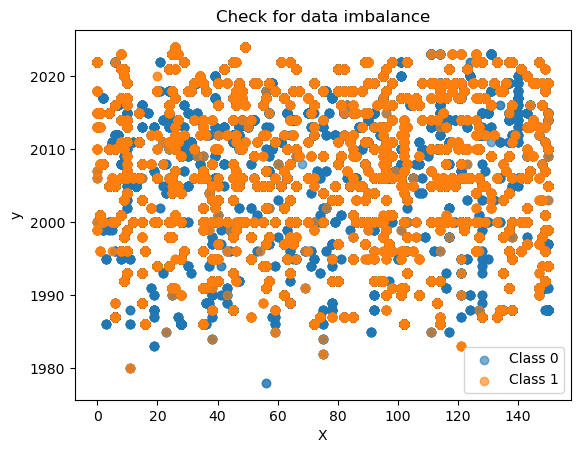

In [94]:

X = df.drop(['low_coverage'], axis=1)  #\
y = df['low_coverage']  # Target column

# Example using iloc to select the first two columns for visualization
plt.scatter(X[y == 0].iloc[:, 0], X[y == 0].iloc[:, 1], label='Class 0', alpha=0.6)
plt.scatter(X[y == 1].iloc[:, 0], X[y == 1].iloc[:, 1], label='Class 1', alpha=0.6)
plt.title('Check for data imbalance')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [95]:
print(f"Class 1 count: {sum(1 for i in y if i == 1)}\nClass 0 count: {sum(1 for i in y if i == 0)}")

Class 1 count: 45323
Class 0 count: 61104


In [96]:
# Ensuring X and y are  integer types

X = X.astype('int')

y = y.astype('int')


Both the feature set (X) and the target variable (y) are converted to integer types to ensure consistency and compatibility with models that require numerical inputs. This step eliminates potential type-related issues during analysis and model training.

#### Resampling the data using SMOTE algorithm

The **Synthetic Minority Oversampling Technique (SMOTE)** is applied to address class imbalance by generating synthetic samples for the minority class. The feature set (`X`) and target variable (`y`) are resampled, resulting in a balanced dataset. A scatter plot of the resampled data visualizes the improved class balance, with `Class 0` and `Class 1` evenly distributed, ensuring a fairer model training process.

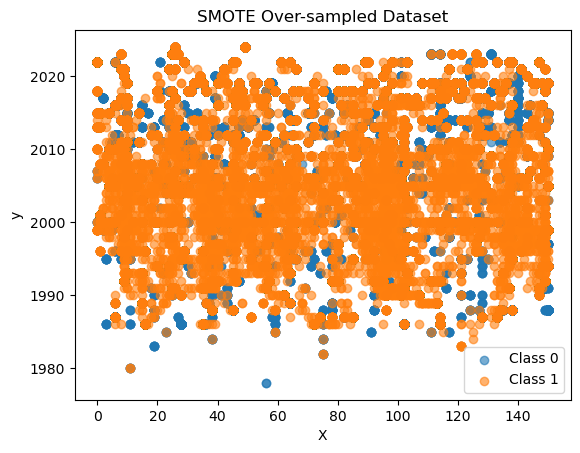

In [97]:


# Apply SMOTE for over-sampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Plotting the SMOTE over-sampled dataset
plt.scatter(X_resampled[y_resampled == 0].iloc[:, 0], X_resampled[y_resampled == 0].iloc[:, 1], label='Class 0', alpha=0.6)
plt.scatter(X_resampled[y_resampled == 1].iloc[:, 0], X_resampled[y_resampled == 1].iloc[:, 1], label='Class 1', alpha=0.6)
plt.title('SMOTE Over-sampled Dataset')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

After applying SMOTE, the resampled target variable (`y_resampled`) is analyzed to verify class balance. A loop is used to count instances of `Class 1` and `Class 0`, and the counts are printed. This step confirms that the oversampling process has successfully balanced the dataset, ensuring both classes are equally represented for model training.

In [98]:
print(f"Class 1 count: {sum(1 for i in y if i == 1)}\nClass 0 count: {sum(1 for i in y if i == 0)}")

Class 1 count: 45323
Class 0 count: 61104


### 3.8 Splitting the Data into Training and Test Sets

The dataset is split into training and testing subsets using `train_test_split`, with 30% allocated for testing and 70% for training. The `stratify` parameter ensures that the class distribution in the target variable (`y_resampled`) remains consistent across both sets. 

In [99]:
from sklearn.model_selection import train_test_split


# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3,stratify =y_resampled, random_state=42)

# Print the sizes of the training and testing sets
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 85545 samples
Test set size: 36663 samples


In [100]:
print(f"Class 1 count: {sum(1 for i in y_test if i == 1)}\nClass 0 count: {sum(1 for i in y_test if i == 0)}")

Class 1 count: 18331
Class 0 count: 18332


In [101]:
print(f"Class 1 count: {sum(1 for i in y_train if i == 1)}\nClass 0 count: {sum(1 for i in y_train if i == 0)}")

Class 1 count: 42773
Class 0 count: 42772


### 3.9 Standardizing Numeric Variables After Splitting

Numerical features in the dataset are standardized using `StandardScaler` to ensure they have a mean of 0 and a standard deviation of 1. The scaler is fitted on the training data (`X_train`) and then applied to transform both the training and testing data (`X_test`). This step ensures consistency in feature scaling, improves model performance, and prevents data leakage by fitting the scaler only on the training data.

In [102]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Apply the scaler to the test data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numeric columns have been standardized after splitting.")

Numeric columns have been standardized after splitting.


### 3.10 Final Dataset Overview

Let's look at the processed training data.

In [103]:
X_train.head()

,country_code,collection_begin,collection_end,cohort_year,vaccine_type,evidence_type,denominator,earliest_vaccination_age,latest_vaccination_age,earliest_interview_age,latest_interview_age,validity_valid,sex_female,sex_male
118866,126,-0.973664,-0.893770,-0.893093,48,3,-0.070935,-0.007253,-0.389160,-0.103143,-0.536848,0,0,0
43394,61,1.768670,1.724249,1.615024,31,3,-0.119263,-0.007253,-0.072506,0.248213,-0.190208,0,0,0
61701,90,1.030349,0.991204,1.092499,0,3,-0.022346,-0.007253,-0.832475,-0.595043,-1.022145,0,0,0
100413,143,0.081080,0.048717,0.151956,0,2,-0.105067,-0.007253,-0.832475,-0.595043,-1.022145,0,0,0
100194,143,0.081080,0.048717,-0.161559,74,0,-0.120463,-0.007253,1.447431,1.934724,1.473667,0,0,1


In [104]:
y_train.head()

118866    1
43394     0
61701     0
100413    0
100194    1
Name: low_coverage, dtype: int64

#### Feature Scaling

In [105]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [106]:
print(len(X_train_scaled))
print(len(X_test_scaled))

85545
36663


## 4. Model Building with MLFlow Tracking

### 4.1 Set MLFlow Experiment

In [5]:
# Define the experiment name
experiment_name = "final_Project_experiment_10.0"

# Set the experiment
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/10', creation_time=1731826672326, experiment_id='10', last_update_time=1731826672326, lifecycle_stage='active', name='final_Project_experiment_10.0', tags={}>

#### Utility functions used in later cells to reduce code redundancy

In [52]:
# Function to log common performance metrics such as accuracy, precision, recall, and F1 score to MLflow.
def log_performance_metrics(y_true, y_pred):
    """
    Logs accuracy, precision, recall, and F1 score metrics to MLflow.
    
    Parameters:
    y_true (array-like): True labels of the test data.
    y_pred (array-like): Predicted labels from the model.
    """
    # Calculate accuracy of the model
    accuracy = accuracy_score(y_true, y_pred)
    # Calculate weighted precision to handle class imbalance
    precision = precision_score(y_true, y_pred, average='weighted')
    # Calculate weighted recall to provide a balanced measure for imbalanced classes
    recall = recall_score(y_true, y_pred, average='weighted')
    # Calculate the F1 score, which combines precision and recall into a single metric
    f1_result = f1_score(y_true, y_pred)

    # Log each metric to MLflow for tracking and comparison
    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("f1_score", f1_result)

# Function to generate, save, and log a confusion matrix plot to MLflow
def plot_and_log_confusion_matrix(y_true, y_pred):
    """
    Plots the confusion matrix and logs it to MLflow as an artifact.
    
    Parameters:
    y_true (array-like): True labels of the test data.
    y_pred (array-like): Predicted labels from the model.
    """
    # Generate a confusion matrix for true vs. predicted labels
    conf_matrix = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))  # Set the figure size
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
    disp.plot(ax=ax, colorbar=False)  # Plot without colorbar for clarity
    ax.set_title("Confusion Matrix")  # Title for the plot
    
    # Save the plot as an image and log it to MLflow
    filename = "confusion_matrix.png"
    plt.tight_layout()  # Ensure the layout fits well
    plt.savefig(filename)  # Save the image
    plt.close()  # Close the figure to free up memory

    # Log the saved image as an artifact in MLflow
    mlflow.log_artifact(filename)

# Function to plot and log the Precision-Recall curve
def plot_and_log_precision_recall_curve(y_true, pred_probs):
    """
    Plots and logs the Precision-Recall curve to MLflow as an artifact.
    
    Parameters:
    y_true (array-like): True labels of the test data.
    pred_probs (array-like): Predicted probabilities for the positive class.
    """
    # Calculate precision and recall at different thresholds
    precision, recall, _ = precision_recall_curve(y_true, pred_probs)
    # Calculate the average precision score for better performance assessment
    average_precision = average_precision_score(y_true, pred_probs)

    # Plot the Precision-Recall curve
    plt.figure(figsize=(8, 6))  # Set the figure size
    plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
    plt.xlabel('Recall')  # Label for x-axis
    plt.ylabel('Precision')  # Label for y-axis
    plt.title('Precision-Recall Curve')  # Title of the plot
    plt.legend()  # Add a legend for clarity
    plt.grid(True)  # Add grid lines for better visualization
    
    # Save the plot and log it
    filename = "precision_recall_curve.png"
    plt.tight_layout()  # Ensure the plot layout is properly displayed
    plt.savefig(filename)  # Save the plot as an image
    plt.close()  # Close the plot to release memory

    # Log the plot as an artifact in MLflow
    mlflow.log_artifact(filename)

# Function to plot and log the ROC curve
def plot_and_log_roc_curve(y_true, pred_probs):
    """
    Plots and logs the ROC curve to MLflow as an artifact.
    
    Parameters:
    y_true (array-like): True labels of the test data.
    pred_probs (array-like): Predicted probabilities for the positive class.
    """
    # Calculate the False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, _ = roc_curve(y_true, pred_probs)
    # Compute the Area Under the Curve (AUC) score for evaluation
    roc_auc = roc_auc_score(y_true, pred_probs)

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))  # Set the figure size
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')  # Baseline
    plt.xlabel('False Positive Rate')  # Label for x-axis
    plt.ylabel('True Positive Rate')  # Label for y-axis
    plt.title('Receiver Operating Characteristic (ROC) Curve')  # Title
    plt.legend()  # Add legend
    plt.grid(True)  # Add grid lines for better visual

    plt.tight_layout()  # Adjust layout
    filename = "ROC_curve.png"
    plt.savefig(filename)  # Save plot
    plt.close()  # Free memory

    mlflow.log_artifact(filename)

# Function to plot and log lift and cumulative gain charts
def plot_and_log_lift_gain_charts(y_true, pred_probs):
    """
    Plots and logs lift and cumulative gain charts to MLflow as an artifact.
    
    Parameters:
    y_true (array-like): True labels.
    pred_probs (array-like): Predicted probabilities for the positive class.
    """
    # Convert y_true to integer type if needed
    y_true = y_true.astype(int)
    # Create a DataFrame with true labels and predicted probabilities
    data = pd.DataFrame({'true': y_true, 'pred_prob': pred_probs})
    # Sort by predicted probabilities in descending order for charting
    data = data.sort_values(by='pred_prob', ascending=False).reset_index(drop=True)
    
    # Calculate cumulative true positives for the gain chart
    data['cumulative_true'] = data['true'].cumsum()
    data['cumulative_gain'] = data['cumulative_true'] / data['true'].sum()

    # Create decile groups for the lift chart
    total_positives = data['true'].sum()
    data['decile'] = pd.qcut(data.index, 10, labels=False)
    lift = data.groupby('decile')['true'].sum() / (total_positives / 10)

    # Plot lift chart
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, 11), lift, marker='o')
    plt.title("Lift Chart")
    plt.xlabel("Decile")
    plt.ylabel("Lift")
    plt.grid(True)

    # Plot cumulative gain chart
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(len(data)) / len(data), data['cumulative_gain'], marker='o', label="Model Gains")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Baseline")
    plt.title("Gains Chart")
    plt.xlabel("Fraction of Total Population")
    plt.ylabel("Cumulative Gain")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()  # Ensure proper layout
    filename = "lift_gain_charts.png"
    plt.savefig(filename)  # Save the figure
    plt.close()  # Close to free memory

    mlflow.log_artifact(filename)  # Log chart to MLflow

### 4.2 Logistic Regression

We build a Logistic Regression model and perform hyperparameter tuning using `RandomizedSearchCV`, exploring 50 random combinations with 5-fold cross-validation to find the best configuration. We define the parameter grid `param_grid` with:  
- **C**: Regularization strengths `[0.01, 0.1, 1, 10, 100]` to control model flexibility.  
- **penalty**: Regularization types `['l1', 'l2']` to explore different sparsity and robustness options.  
- **solver**: Optimization solvers `['saga', 'liblinear']` suitable for small to large datasets.  
- **max_iter**: Iterations `[1000, 5000]` for convergence under different complexities.  
- **tol**: Tolerance levels `[1e-4, 1e-3]` to refine stopping criteria.  

The tuned model’s parameters and performance metrics, including accuracy, precision, and recall, are logged to MLflow for tracking. A confusion matrix and AUC-ROC curve are generated to evaluate classification performance and saved as artifacts. Lift and gains charts are also calculated to assess the model’s predictive power, with all outputs securely stored in MLflow for detailed analysis and reproducibility.

In [46]:
# Disable MLflow's automatic logging to avoid potential conflicts when logging custom metrics and artifacts manually
mlflow.sklearn.autolog(disable=True)

# Instantiate a Logistic Regression model with specified maximum iterations and tolerance for better convergence
log_reg = LogisticRegression(max_iter=4000, tol=1e-4)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Regularization strength; smaller values specify stronger regularization
    'penalty': ['l2', 'l1'],               # Regularization types (L2 is Ridge, L1 is Lasso)
    'solver': ['saga', 'liblinear'],       # Solvers for optimization (SAGA supports L1, L2; liblinear is good for small datasets)
    'max_iter': [5000],                    # Number of iterations for solver convergence
    'tol': [1e-4, 1e-3],                   # Tolerance for stopping criteria; lower values lead to more precise solutions
}

# Set up RandomizedSearchCV for hyperparameter tuning with cross-validation
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_grid,
    n_iter=50,               # Number of parameter settings sampled
    scoring='f1',            # Metric for model evaluation; F1-score balances precision and recall
    cv=5,                    # 5-fold cross-validation to ensure robustness
    verbose=0,               # Verbose set to 0 for minimal output
    random_state=42,         # Random state for reproducibility
    n_jobs=-1                # Use all available cores for parallel processing
)

# Start a new MLflow run to track the experiment
with mlflow.start_run(run_name="Logistic Regression- manual") as run:
    
    # Fit the model using random search to find the best hyperparameters
    random_search.fit(X_train_scaled, y_train)
    
    # Retrieve and log the best hyperparameters found during the search
    best_params = random_search.best_params_
    mlflow.log_params(best_params)
    
    # Get the best model from the search and make predictions on the test set
    best_log_reg = random_search.best_estimator_
    y_pred_log_reg = best_log_reg.predict(X_test_scaled)

    # Log the best model to MLflow with an input example and signature for reproducibility
    input_example = X_test_scaled[:5]
    signature = infer_signature(X_test_scaled, y_pred_log_reg)
    mlflow.sklearn.log_model(best_log_reg, "best_log_reg", signature=signature, input_example=input_example)
    
    # Log various performance metrics (accuracy, precision, recall, F1 score)
    log_performance_metrics(y_test, y_pred_log_reg)

    # Generate and log a confusion matrix plot as an artifact
    plot_and_log_confusion_matrix(y_test, y_pred_log_reg)

    # Obtain predicted probabilities for the positive class from the best model
    logistic_probs = best_log_reg.predict_proba(X_test_scaled)[:, 1]

    # Plot and log the Precision-Recall curve as an artifact
    plot_and_log_precision_recall_curve(y_test, logistic_probs)

    # Plot and log the ROC curve as an artifact
    plot_and_log_roc_curve(y_test, logistic_probs)
    
    # Plot and log lift and cumulative gain charts as an artifact
    plot_and_log_lift_gain_charts(y_test, logistic_probs)
    
    # End the MLflow run (optional as the `with` statement handles this)
    mlflow.end_run()
    
    # Notify the user that the MLflow run has completed
    print("MLflow run completed. Check your MLflow UI for logged metrics and artifacts.")

2024/11/17 02:57:14 INFO mlflow.tracking._tracking_service.client: 🏃 View run Logistic Regression- manual at: http://131.247.92.12:5013/#/experiments/10/runs/4252f48b583a4743acbc975e1373211a.
2024/11/17 02:57:14 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://131.247.92.12:5013/#/experiments/10.


MLflow run completed. Check your MLflow UI for logged metrics and artifacts.


### 4.3 Random Forest

We build a Random Forest model and perform hyperparameter tuning using `RandomizedSearchCV`, exploring 50 random combinations with 5-fold cross-validation to find the optimal configuration. We define the parameter grid `param_grid` with:  
- **n_estimators**: Number of trees in the forest `[100, 200, 300, 400, 500]` to explore model depth and complexity.  
- **max_depth**: Maximum depth of each tree `[10, 20, 30, None]` to balance underfitting and overfitting.  
- **min_samples_split**: Minimum number of samples required to split an internal node `[2, 5, 10]` for controlling tree branching.  
- **min_samples_leaf**: Minimum number of samples required to be at a leaf node `[1, 2, 4, 6]` to manage tree size.  
- **bootstrap**: Whether to use bootstrapping `True/False` for sampling data during tree construction.  

The tuned model’s parameters and performance metrics, including accuracy, precision, recall, F1-score, and AUC-ROC, are logged to MLflow for tracking. To evaluate the model’s classification performance, a confusion matrix and AUC-ROC curve are generated and saved as artifacts. Additionally, lift and gains charts are calculated to assess the model’s predictive effectiveness.

In [47]:
# Disable MLflow's autologging to avoid conflicts with manual logging
mlflow.sklearn.autolog(disable=True)

# Initialize the Random Forest classifier with a fixed random seed for reproducibility
rf = RandomForestClassifier(random_state=42)

# Define an expanded parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],  # Different tree counts to enhance model performance
    'max_depth': [10, 20, 30, None],              # Depth of trees, None means no limit
    'min_samples_split': [2, 5, 10],              # Minimum samples needed to split an internal node
    'min_samples_leaf': [1, 2, 4, 6],             # Minimum samples to be at a leaf node
    'max_features': ['sqrt', 'log2', None],      # Number of features to consider at each split
    'bootstrap': [True, False],                   # Whether to use bootstrap sampling for trees
    'class_weight': ['balanced', None],           # Adjust for class imbalance
    'max_samples': [None, 0.5, 0.8],              # Fraction of samples for each base estimator
}

# Set up RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,  # Increase the number of random combinations to test
    scoring='f1',  # Use F1 score to evaluate the model
    cv=5,  # 5-fold cross-validation to ensure robustness
    verbose=0,  # Minimal output during fitting
    random_state=42,
    n_jobs=-1  # Use all available cores for faster computation
)

# Start a new MLflow run for tracking
with mlflow.start_run(run_name="RandomForest - manual") as run:
    
    # Perform RandomizedSearchCV to find the best hyperparameters
    random_search.fit(X_train_scaled, y_train)
    
    # Log the best parameters found during the random search
    best_params = random_search.best_params_
    mlflow.log_params(best_params)
    
    # Get the best model from the search and make predictions on the test set
    best_rf = random_search.best_estimator_
    y_pred_rf = best_rf.predict(X_test_scaled)
    
    # Log the best model as an artifact to MLflow
    input_example = X_test_scaled[:5]
    signature = infer_signature(X_test_scaled, y_pred_rf)
    mlflow.sklearn.log_model(best_rf, "best_rf", signature=signature, input_example=input_example)

    # Log performance metrics (accuracy, precision, recall, F1 score)
    log_performance_metrics(y_test, y_pred_rf)
    
    # Generate and log the confusion matrix as an artifact
    plot_and_log_confusion_matrix(y_test, y_pred_rf)
    
    # Get predicted probabilities for the positive class
    rf_probs = best_rf.predict_proba(X_test_scaled)[:, 1]

    # Log the Precision-Recall curve
    plot_and_log_precision_recall_curve(y_test, rf_probs)

    # Log the ROC curve
    plot_and_log_roc_curve(y_test, rf_probs)
    
    # Log lift and gain charts
    plot_and_log_lift_gain_charts(y_test, rf_probs)

# End the MLflow run 
mlflow.end_run()

# Notify the user that the MLflow run is completed
print("MLflow run completed. Check your MLflow UI for logged metrics and artifacts.")

2024/11/17 03:09:56 INFO mlflow.tracking._tracking_service.client: 🏃 View run RandomForest - manual at: http://131.247.92.12:5013/#/experiments/10/runs/7cb880b330ae43fd90bf0302f1dea08a.
2024/11/17 03:09:56 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://131.247.92.12:5013/#/experiments/10.


MLflow run completed. Check your MLflow UI for logged metrics and artifacts.


### 4.4 Decision Tree

We build a **Decision Tree Classifier** and perform hyperparameter tuning using `RandomizedSearchCV`, evaluating 50 random combinations with 5-fold cross-validation to identify the optimal configuration. The parameter grid `param_grid` includes:  
- **criterion**: Splitting criteria `['gini', 'entropy', 'log_loss']` to explore trade-offs between information gain and classification quality.  
- **max_depth**: Tree depth `[None, 10, 20, 40, 50]` to balance model complexity and generalization.  
- **min_samples_split**: Minimum samples required to split a node `[2, 5, 8, 12]` for controlling over-splitting.  
- **min_samples_leaf**: Minimum samples at a leaf node `[1, 2, 5, 10]` to avoid overly specific splits.  
- **max_features**: Feature selection methods `['sqrt', 'log2', None, 0.75]` to explore dimensionality reduction and proportional feature selection.  
- **class_weight**: Weighting options `['balanced', 'balanced_subsample', None]` to handle class imbalances effectively.  

The tuned model’s hyperparameters, along with key performance metrics such as accuracy, precision, recall, and F1-Score, are logged to MLflow for tracking and reproducibility. 

In [66]:
# Disable MLflow's automatic logging to prevent interference with manual logging during the experiment
mlflow.sklearn.autolog(disable=True)

# Initialize a Decision Tree Classifier with a fixed random seed for reproducibility
dt = DecisionTreeClassifier(random_state=42)

# Define the grid of hyperparameters to explore during tuning
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],  # Criteria for splitting nodes, including log_loss for classification improvements
    'max_depth': [None, 10, 20, 40, 50],           # Possible maximum depths of the tree to prevent overfitting
    'min_samples_split': [2, 5, 8, 12],            # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 5, 10],             # Minimum samples required to be at a leaf node for better generalization
    'max_features': ['sqrt', 'log2', None, 0.75],  # Feature selection methods, including a custom proportion (0.75)
    'class_weight': ['balanced', 'balanced_subsample', None],  # Options for handling class imbalance
}

# Set up RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=dt,                           # The base model to optimize
    param_distributions=param_grid,         # Distribution of parameters to sample
    n_iter=50,                              # Number of random parameter combinations to evaluate
    scoring='f1',                           # Performance metric for model evaluation
    cv=5,                                   # Number of cross-validation folds
    verbose=0,                              # Suppress verbose output
    random_state=42,                        # Random seed for reproducibility
    n_jobs=-1                               # Use all available processors for parallelization
)

# Begin an MLflow experiment run with a custom run name
with mlflow.start_run(run_name="DecisionTree - manual") as run:
    
    # Train the model and search for the best hyperparameters using the training data
    random_search.fit(X_train_scaled, y_train)
    
    # Extract the best parameters and log them to MLflow
    best_params = random_search.best_params_
    mlflow.log_params(best_params)
    
    # Retrieve the best model identified during the search
    best_dt = random_search.best_estimator_
    
    # Generate predictions on the test dataset using the best model
    y_pred_dt = best_dt.predict(X_test_scaled)
    
    # Log the best model to MLflow as an artifact, including its input signature for traceability
    input_example = X_test_scaled[:5]                    # Example inputs for model illustration
    signature = infer_signature(X_test_scaled, y_pred_dt)  # Define the input-output signature for the model
    mlflow.sklearn.log_model(best_dt, "best_dt", signature=signature, input_example=input_example)

    # Log key performance metrics such as accuracy, precision, recall, and F1 score
    log_performance_metrics(y_test, y_pred_dt)
    
    # Log a visual representation of the confusion matrix for model evaluation
    plot_and_log_confusion_matrix(y_test, y_pred_dt)
    
    # Generate and log the predicted probabilities for the positive class
    dt_probs = best_dt.predict_proba(X_test_scaled)[:, 1]

    # Log Precision-Recall Curve
    plot_and_log_precision_recall_curve(y_test, dt_probs)
    
    # Log Receiver Operating Characteristic (ROC) Curve
    plot_and_log_roc_curve(y_test, dt_probs)
    
    # Log Lift and Gain charts 
    plot_and_log_lift_gain_charts(y_test, dt_probs)
    
    # End the current MLflow experiment run
    mlflow.end_run()

# Notify the user that the MLflow run has completed.
print("MLflow run completed. Check your MLflow UI for logged metrics and artifacts.")

2024/11/17 11:57:07 INFO mlflow.tracking._tracking_service.client: 🏃 View run DecisionTree - manual at: http://131.247.92.12:5013/#/experiments/10/runs/cc3b2d6e3a234b8ab09bfd82c2a5900c.
2024/11/17 11:57:07 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://131.247.92.12:5013/#/experiments/10.


MLflow run completed. Check your MLflow UI for logged metrics and artifacts.


### 4.5 K-Nearest Neighbors(KNN)

We build a **K-Nearest Neighbors (KNN) classifier** and perform hyperparameter tuning using `RandomizedSearchCV`, exploring 50 random combinations with 5-fold cross-validation to identify the optimal configuration. The parameter grid `param_grid_knn` includes:  
- **n_neighbors**: Number of neighbors `[3, 5, 7, 9, 11]` to control the flexibility and smoothness of decision boundaries.  
- **weights**: Neighbor weighting strategies `['uniform', 'distance']` to determine the influence of each neighbor.  
- **algorithm**: Search algorithms `['auto', 'ball_tree', 'kd_tree', 'brute']` to optimize the neighbor search process.  
- **p**: Minkowski distance power parameter `[1, 2]`, enabling Manhattan (1) or Euclidean (2) distance metrics.  

The tuned model’s hyperparameters, along with key performance metrics such as accuracy, precision, recall, and F1-Score, are logged to MLflow for tracking. 

In [57]:
# Disable MLflow's automatic logging to avoid conflicts with manual logging during the experiment
mlflow.sklearn.autolog(disable=True)

# Initialize the K-Nearest Neighbors (KNN) classifier
knn = KNeighborsClassifier()

# Define the parameter grid to explore hyperparameter options for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],         # Number of nearest neighbors to consider
    'weights': ['uniform', 'distance'],      # Weighting strategies for neighbors' contributions
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Neighbor search algorithms
    'p': [1, 2]                              # Power parameter for Minkowski distance (1 = Manhattan, 2 = Euclidean)
}

# Configure RandomizedSearchCV for hyperparameter tuning with KNN
random_search_knn = RandomizedSearchCV(
    estimator=knn,                          # The base KNN model to optimize
    param_distributions=param_grid_knn,     # Hyperparameter options to sample
    n_iter=50,                              # Number of random combinations to evaluate
    scoring='accuracy',                     # Performance metric for model evaluation
    cv=5,                                   # Number of cross-validation folds
    verbose=2,                              # Verbosity level for progress updates
    random_state=42,                        # Random seed for reproducibility
    n_jobs=-1                               # Use all available CPUs for parallel computation
)

# Begin a new MLflow run with a descriptive run name
with mlflow.start_run(run_name="KNN - manual") as run:

    # Train the model using RandomizedSearchCV to find the best hyperparameters
    random_search_knn.fit(X_train_scaled, y_train)

    # Extract and log the best hyperparameters identified during the search
    best_params_knn = random_search_knn.best_params_
    mlflow.log_params(best_params_knn)

    # Retrieve the best KNN model found
    best_knn = random_search_knn.best_estimator_
    
    # Generate predictions on the test dataset using the best model
    y_pred_knn = best_knn.predict(X_test_scaled)

    # Log the best KNN model as an artifact, with an input-output signature and example inputs
    input_example_knn = X_test_scaled[:5]                   # Example test inputs
    signature_knn = infer_signature(X_test_scaled, y_pred_knn)  # Define the model signature
    mlflow.sklearn.log_model(best_knn, "best_knn", signature=signature_knn, input_example=input_example_knn)

    # Log key performance metrics (accuracy, precision, recall, F1 score, etc.)
    log_performance_metrics(y_test, y_pred_knn)
    
    # Log a confusion matrix to provide insight into classification performance
    plot_and_log_confusion_matrix(y_test, y_pred_knn)

    # Generate predicted probabilities for the positive class
    knn_probs = best_knn.predict_proba(X_test_scaled)[:, 1]

    # Log a Precision-Recall Curve to analyze precision-recall trade-offs
    plot_and_log_precision_recall_curve(y_test, knn_probs)

    # Log an ROC Curve to evaluate true positive vs. false positive rates
    plot_and_log_roc_curve(y_test, knn_probs)
    
    # Log Lift and Gain charts to assess the model's effectiveness in ranking outcomes
    plot_and_log_lift_gain_charts(y_test, knn_probs)
    
    # End the current MLflow experiment run
    mlflow.end_run()

# Notify the user that the MLflow run for KNN is complete
print("MLflow run for KNN completed. Check the MLflow UI for results.")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


2024/11/17 10:55:49 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN - manual at: http://131.247.92.12:5013/#/experiments/10/runs/d4f30071fd834a508d3e63efe9bb3a74.
2024/11/17 10:55:49 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://131.247.92.12:5013/#/experiments/10.


MLflow run for KNN completed. Check the MLflow UI for results.


### 4.6 XGBoost

We build an XGBoost classifier and perform hyperparameter tuning using `RandomizedSearchCV`, exploring 50 random combinations with 5-fold cross-validation to find the optimal configuration. The parameter grid `param_grid` is defined with:  
- **n_estimators**: Number of trees `[100, 200, 300, 400, 500]` to control model complexity.  
- **max_depth**: Maximum depth of trees `[3, 6, 10, 12, 15]` to balance underfitting and overfitting.  
- **learning_rate**: Learning rates `[0.01, 0.05, 0.1, 0.2]` to manage the step size for updates.  
- **subsample**: Fraction of samples `[0.6, 0.8, 1.0]` used for training each tree.  
- **colsample_bytree**: Fraction of features `[0.6, 0.8, 1.0]` considered at each split.  
- **min_child_weight**: Minimum sum of instance weights `[1, 3, 5, 7]` for a child node.  
- **gamma**: Regularization term `[0, 0.1, 0.2, 0.3]` to control tree complexity.  
- **reg_alpha**: L1 regularization `[0, 0.1, 1]` for feature selection.  
- **reg_lambda**: L2 regularization `[0, 0.1, 1]` for model stability.  
- **scale_pos_weight**: Adjustment `[1, 10, 50]` for imbalanced classes.  

The best model’s parameters are logged to MLflow along with metrics such as accuracy, precision, recall, F1-score, and AUC-ROC. A confusion matrix and AUC-ROC curve are generated to visualize performance, and lift and gains charts are calculated to assess predictive power. 

In [53]:
# Disable MLflow's automatic logging to avoid conflicts with manually specified logging
mlflow.sklearn.autolog(disable=True)

# Initialize the XGBoost classifier with a specified evaluation metric and random state
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# Define a grid of hyperparameters for the XGBoost model to explore
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],   # Number of boosting rounds
    'max_depth': [3, 6, 10, 12, 15],             # Depth of each tree, balancing flexibility and overfitting
    'learning_rate': [0.01, 0.05, 0.1, 0.2],     # Step size shrinkage for model updates
    'subsample': [0.6, 0.8, 1.0],                # Fraction of training samples per tree
    'colsample_bytree': [0.6, 0.8, 1.0],         # Fraction of features considered per tree
    'min_child_weight': [1, 3, 5, 7],            # Minimum weight sum of child nodes
    'gamma': [0, 0.1, 0.2, 0.3],                 # Regularization for controlling tree splits
    'reg_alpha': [0, 0.1, 1],                    # L1 regularization term
    'reg_lambda': [0, 0.1, 1],                   # L2 regularization term
    'scale_pos_weight': [1, 10, 50]              # Scaling factor for handling class imbalance
}

# Set up RandomizedSearchCV to tune hyperparameters with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_clf,                      # Base model for optimization
    param_distributions=param_grid,         # Grid of hyperparameter options
    n_iter=50,                              # Number of random parameter combinations to evaluate
    scoring='f1',                           # Performance metric; adjust based on your goals
    cv=5,                                   # 5-fold cross-validation for reliable evaluation
    verbose=0,                              # Suppress detailed output
    random_state=42,                        # Random seed for reproducibility
    n_jobs=-1                               # Utilize all available CPUs for faster execution
)

# Begin a new MLflow run with a descriptive run name
with mlflow.start_run(run_name="XGBoost - manual") as run:
    
    # Train the model using RandomizedSearchCV to find the best hyperparameters
    random_search.fit(X_train_scaled, y_train)
    
    # Extract and log the best hyperparameters identified during the search
    best_params = random_search.best_params_
    mlflow.log_params(best_params)
    
    # Retrieve the best XGBoost model from the random search
    best_xgb = random_search.best_estimator_
    
    # Generate predictions on the test dataset
    y_pred_xgb = best_xgb.predict(X_test_scaled)
        
    # Log the best model artifact, including an example input and model signature for reproducibility
    input_example = X_test_scaled[:5]                    # Example test inputs
    signature = infer_signature(X_test_scaled, y_pred_xgb)  # Input-output signature for the model
    mlflow.sklearn.log_model(best_xgb, "best_xgb", signature=signature, input_example=input_example)

    # Log key performance metrics, such as accuracy, precision, recall, and F1 score
    log_performance_metrics(y_test, y_pred_xgb)
    
    # Log a confusion matrix to evaluate classification performance visually
    plot_and_log_confusion_matrix(y_test, y_pred_xgb)

    # Generate predicted probabilities for the positive class
    xgb_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

    # Log a Precision-Recall Curve to understand trade-offs between precision and recall
    plot_and_log_precision_recall_curve(y_test, xgb_probs)

    # Log an ROC Curve to evaluate true positive rates vs. false positive rates
    plot_and_log_roc_curve(y_test, xgb_probs)
    
    # Log Lift and Gain charts to assess the model's effectiveness in ranking positive outcomes
    plot_and_log_lift_gain_charts(y_test, xgb_probs)
    
    # End the current MLflow run
    mlflow.end_run()

# Notify the user that the MLflow run is complete
print("MLflow run completed. Check your MLflow UI for logged metrics and artifacts.")

2024/11/17 07:33:49 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost - manual at: http://131.247.92.12:5013/#/experiments/10/runs/41adcf32bf4e483b83da78b0567c97ab.
2024/11/17 07:33:49 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://131.247.92.12:5013/#/experiments/10.


MLflow run completed. Check your MLflow UI for logged metrics and artifacts.


### 4.7 MLPClassifier

We build an MLP Classifier and perform hyperparameter tuning using `RandomizedSearchCV`, exploring 20 random combinations with 3-fold cross-validation for efficient optimization. The parameter grid `param_grid` is defined with:  
- **hidden_layer_sizes**: Configurations `[(50,), (100,), (50, 100)]` to control the network architecture.  
- **activation**: Activation functions `['tanh', 'relu']` to test different non-linearities.  
- **solver**: Optimization solver `['adam']`, known for stability in neural network training.  
- **learning_rate**: Learning strategies `['constant', 'adaptive']` for flexibility during updates.  
- **learning_rate_init**: Initial learning rates `[0.001, 0.01]` to manage step sizes.  
- **alpha**: L2 regularization terms `[0.0001, 0.001]` to prevent overfitting.  
- **batch_size**: Batch sizes `['auto', 64]` to explore computation efficiency.  

The best model’s parameters are logged to MLflow along with metrics such as accuracy, precision, recall, F1-score, and AUC-ROC. A confusion matrix and AUC-ROC curve are generated to visualize performance, and lift and gains charts are calculated to assess predictive power.

In [56]:
# Disable MLflow's automatic logging to prevent interference with manual logging
mlflow.sklearn.autolog(disable=True)

# Initialize the Multi-Layer Perceptron (MLP) classifier with an increased max_iter for better convergence
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Define a streamlined parameter grid to explore hyperparameter options for the MLP
param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],        # Options for the number of neurons in the hidden layers
    'activation': ['tanh', 'relu'],              # Activation functions to try for non-linearity
    'solver': ['adam'],                          # Solver choice focusing on stability and efficiency
    'learning_rate': ['constant', 'adaptive'],   # Learning rate schedules for training dynamics
    'learning_rate_init': [0.001, 0.01],         # Initial learning rates for optimization
    'alpha': [0.0001, 0.001],                    # L2 regularization strength for controlling overfitting
    'batch_size': ['auto', 64]                   # Batch size options for training iterations
}

# Set up RandomizedSearchCV to tune MLP hyperparameters with reduced computational cost
random_search = RandomizedSearchCV(
    estimator=mlp,                             # Base MLP model for optimization
    param_distributions=param_grid,            # Hyperparameter options
    n_iter=15,                                 # Number of random parameter combinations to evaluate
    scoring='accuracy',                        # Performance metric for evaluation
    cv=3,                                      # 3-fold cross-validation to balance speed and reliability
    verbose=0,                                 # Suppress detailed output
    random_state=42,                           # Random seed for reproducibility
    n_jobs=-1                                  # Utilize all available CPUs for parallel execution
)

# Begin a new MLflow run with a descriptive run name
with mlflow.start_run(run_name="MLPClassifier") as run:
    # Perform random search to find the best hyperparameters
    random_search.fit(X_train_scaled, y_train)
    
    # Retrieve the best MLP model from the random search
    best_mlp = random_search.best_estimator_
    
    # Log the best hyperparameters identified during the search
    mlflow.log_param("hidden_layer_sizes", best_mlp.hidden_layer_sizes)
    mlflow.log_param("activation", best_mlp.activation)
    mlflow.log_param("solver", best_mlp.solver)
    mlflow.log_param("max_iter", best_mlp.max_iter)
    mlflow.log_param("learning_rate", best_mlp.learning_rate)
    mlflow.log_param("learning_rate_init", best_mlp.learning_rate_init)
    mlflow.log_param("alpha", best_mlp.alpha)
    mlflow.log_param("batch_size", best_mlp.batch_size)

    # Generate predictions on the test dataset using the best model
    y_pred_mlp = best_mlp.predict(X_test_scaled)

    # Log key performance metrics such as accuracy, precision, recall, and F1 score
    log_performance_metrics(y_test, y_pred_mlp)
    
    # Log a confusion matrix to visually assess classification performance
    plot_and_log_confusion_matrix(y_test, y_pred_mlp)

    # Get predicted probabilities for the positive class
    MLPC_probs = best_mlp.predict_proba(X_test_scaled)[:, 1]

    # Log a Precision-Recall Curve to analyze precision-recall trade-offs
    plot_and_log_precision_recall_curve(y_test, MLPC_probs)

    # Log an ROC Curve to evaluate true positive vs. false positive rates
    plot_and_log_roc_curve(y_test, MLPC_probs)
    
    # Log Lift and Gain charts to evaluate the model's ability to rank positive outcomes
    plot_and_log_lift_gain_charts(y_test, MLPC_probs)

    # Log the trained MLP model as an artifact for reproducibility and sharing
    mlflow.sklearn.log_model(best_mlp, "mlp_model")
    
    # End the current MLflow run
    mlflow.end_run()
 
# Notify the user that the MLflow run is complete
print("MLflow run completed. Check your MLflow UI for logged metrics and artifacts.")

2024/11/17 10:41:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2024/11/17 10:41:28 INFO mlflow.tracking._tracking_service.client: 🏃 View run MLPClassifier at: http://131.247.92.12:5013/#/experiments/10/runs/d2fa4c5393234d0b8a489e6b37caa28d.
2024/11/17 10:41:28 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://131.247.92.12:5013/#/experiments/10.


MLflow run completed. Check your MLflow UI for logged metrics and artifacts.


###  From Top Performer to Deployment: Elevating the Best Model Across Stages

###  Identifying the Best Run
 
We can query the MLflow tracking server to find the best run based on test metrics

In [6]:
# Search for runs in the experiment
experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=experiment.experiment_id)

In [7]:
runs_df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.Precision,metrics.Accuracy,metrics.f1_score,metrics.Recall,...,params.bootstrap,params.max_samples,params.tol,params.C,params.penalty,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.log-model.history
0,e374891ec28c49ee8e0de6dd46553f44,10,RUNNING,mlflow-artifacts:/10/e374891ec28c49ee8e0de6dd4...,2024-11-17 18:16:08.918000+00:00,NaT,NaN,NaN,NaN,NaN,...,None,None,None,None,None,thundering-mole-710,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,None
1,cc3b2d6e3a234b8ab09bfd82c2a5900c,10,FINISHED,mlflow-artifacts:/10/cc3b2d6e3a234b8ab09bfd82c...,2024-11-17 16:56:54.285000+00:00,2024-11-17 16:57:06.768000+00:00,0.938358,0.938357,0.938369,0.938357,...,None,None,None,None,None,DecisionTree - manual,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,"[{""run_id"": ""cc3b2d6e3a234b8ab09bfd82c2a5900c""..."
2,d4f30071fd834a508d3e63efe9bb3a74,10,FINISHED,mlflow-artifacts:/10/d4f30071fd834a508d3e63efe...,2024-11-17 15:45:53.303000+00:00,2024-11-17 15:55:48.990000+00:00,0.867414,0.867414,0.867479,0.867414,...,None,None,None,None,None,KNN - manual,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,"[{""run_id"": ""d4f30071fd834a508d3e63efe9bb3a74""..."
3,d2fa4c5393234d0b8a489e6b37caa28d,10,FINISHED,mlflow-artifacts:/10/d2fa4c5393234d0b8a489e6b3...,2024-11-17 15:38:12.020000+00:00,2024-11-17 15:41:28.671000+00:00,0.840741,0.840739,0.840947,0.840739,...,None,None,None,None,None,MLPClassifier,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,"[{""run_id"": ""d2fa4c5393234d0b8a489e6b37caa28d""..."
4,41adcf32bf4e483b83da78b0567c97ab,10,FINISHED,mlflow-artifacts:/10/41adcf32bf4e483b83da78b05...,2024-11-17 12:32:33.699000+00:00,2024-11-17 12:33:49.021000+00:00,0.966700,0.966697,0.966653,0.966697,...,None,None,None,None,None,XGBoost - manual,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,"[{""run_id"": ""41adcf32bf4e483b83da78b0567c97ab""..."
5,7cb880b330ae43fd90bf0302f1dea08a,10,FINISHED,mlflow-artifacts:/10/7cb880b330ae43fd90bf0302f...,2024-11-17 08:02:03.708000+00:00,2024-11-17 08:09:56.132000+00:00,0.945595,0.945504,0.945110,0.945504,...,True,0.5,None,None,None,RandomForest - manual,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,"[{""run_id"": ""7cb880b330ae43fd90bf0302f1dea08a""..."
6,4252f48b583a4743acbc975e1373211a,10,FINISHED,mlflow-artifacts:/10/4252f48b583a4743acbc975e1...,2024-11-17 07:54:12.346000+00:00,2024-11-17 07:57:14.287000+00:00,0.614109,0.613070,0.593664,0.613070,...,None,None,0.0001,1,l2,Logistic Regression- manual,pranaytalluri,LOCAL,/opt/anaconda3/envs/mlflow_env/lib/python3.12/...,"[{""run_id"": ""4252f48b583a4743acbc975e1373211a""..."


## 5. Model Performance Comparison and Interpretation

### 5.1 Performance Metrics for All Models 

| Model                  | Accuracy | Precision | Recall | F1-Score |
|-------------------------|----------|-----------|--------|----------|
| **Logistic Regression** | 0.9125   | 0.9130    | 0.9125 | 0.9127   |
| **Random Forest**       | 0.9455   | 0.9456    | 0.9455 | 0.9451   |
| **Decision Tree**       | 0.9384   | 0.9384    | 0.9384 | 0.9387   |
| **KNN**                 | 0.8674   | 0.8674    | 0.8674 | 0.8675   |
| **XGBoost**             | 0.9667   | 0.9670    | 0.9667 | 0.9667   |
| **MLP Classifier**      | 0.8407   | 0.8407    | 0.8407 | 0.8409   |

---

### 5.2 Comparison of Models

#### 5.2.1 **Logistic Regression**
- **Strengths**:
  - High interpretability and ease of implementation.
  - Solid F1-Score of 0.9127, indicating balanced performance for both precision and recall.
- **Weaknesses**:
  - Slightly less accurate than Random Forest and XGBoost.
  - Simpler decision boundaries may not capture complex relationships.
    
#### 5.2.2 **Random Forest**
- **Strengths**:
  - Robust accuracy (0.9455) and F1-Score (0.9451).
  - Handles imbalanced data well due to its class-weighted adjustments.
- **Weaknesses**:
  - Computationally more expensive than Logistic Regression.
  - Less interpretable than simpler models.

#### 5.2.3 **Decision Tree**
- **Strengths**:
  - Simple and interpretable with a competitive F1-Score (0.9387).
  - Handles non-linear relationships effectively.
- **Weaknesses**:
  - Prone to overfitting compared to ensemble methods like Random Forest.

#### 5.2.4 **KNN**
- **Strengths**:
  - Decent accuracy (0.8674) and F1-Score (0.8675).
  - Works well for smaller datasets and non-parametric scenarios.
- **Weaknesses**:
  - Computational cost increases with data size.
  - Sensitive to the choice of distance metric and the number of neighbors.

#### 5.2.5 **XGBoost**
- **Strengths**:
  - Best overall performance with an F1-Score of 0.9667.
  - Excels in precision and recall, minimizing both false positives and negatives.
  - Highly efficient and robust for large, complex datasets.
- **Weaknesses**:
  - Computationally intensive and requires careful tuning.
  - Less interpretable compared to simpler models.

#### 5.2.6 **MLP Classifier**
- **Strengths**:
  - Captures non-linear relationships with hidden layers.
  - Decent performance in PR and ROC curves.
- **Weaknesses**:
  - Lowest F1-Score (0.8409) among all models.
  - Requires more data and careful hyperparameter tuning to achieve better results.

---


### 5.4 Recommendation
- **Best Model**: XGBoost, for its superior F1-Score and ability to minimize false positives and negatives.
- **Alternative Choice**: Random Forest or Decision Tree, for their strong balance between accuracy and interpretability.
- **Simpler Use Case**: Logistic Regression, if interpretability and ease of implementation are prioritized.


## 6. Conclusion: Identifying the Best Model for Increasing Vaccination Coverage  

The objective of this project was to develop a predictive model to identify high-risk regions with low vaccination coverage, ensuring timely and effective public health interventions. Given the business problem's critical focus on minimizing both false positives and false negatives, the evaluation criteria centered on the **F1-Score**, as it provides a balanced measure of Precision and Recall.



### **6.1 Top Performer: XGBoost**
- **Why XGBoost?**  
  XGBoost emerged as the most effective model, achieving an **F1-Score of 0.967** and excelling in all key metrics, including an AUC of 0.99 and high Precision and Recall. Its advanced ensemble-based approach captured complex patterns in the data, making it particularly suited for identifying high-risk regions where socio-economic and geographic disparities impact vaccination rates.  
- **Impact on Business Problem:**  
  - **High Precision:** Reduces the risk of incorrectly identifying regions as high-risk (false positives), ensuring that resources are not wasted.  
  - **High Recall:** Ensures most regions with genuine immunization gaps are flagged, minimizing missed opportunities for intervention.  
  - **Actionable Insights:** XGBoost’s ability to handle imbalanced datasets ensures robust predictions, critical for optimizing vaccination campaigns and tailoring region-specific strategies.



### **6.2 Supporting Model: Random Forest**
- **Why Random Forest?**  
  As the runner-up, Random Forest demonstrated solid performance with an **F1-Score of 0.945** and an equally strong AUC of 0.99. Its simplicity and interpretability make it a viable alternative, especially for organizations needing more transparent models.  
- **Impact on Business Problem:**  
  Random Forest provides reliable predictions while maintaining the balance between Precision and Recall, making it useful for generalizable scenarios where computational efficiency and model explainability are key.



### **6.3 Other Models:**
- **Logistic Regression and Decision Tree:** These models performed well, with F1-Scores of 0.935 and 0.939, respectively, but lacked the advanced predictive power of XGBoost and Random Forest. They may be suitable for smaller datasets or as baseline models in future analyses.  
- **KNN and MLP Classifier:** These models underperformed with F1-Scores below 0.87, making them less suitable for this critical public health challenge, as their higher misclassification rates could lead to missed interventions or resource misallocations.



### **6.4 Recommendation: XGBoost for Scalable Public Health Impact**
XGBoost is the clear choice for addressing low vaccination rates due to its superior ability to accurately predict high-risk regions with minimal false positives and negatives. By deploying this model, health organizations can:  
1. **Prioritize Interventions:** Accurately identify regions in urgent need of vaccination campaigns.  
2. **Optimize Resource Allocation:** Focus limited resources on areas with the highest impact potential.  
3. **Customize Strategies:** Provide actionable insights tailored to the unique socio-economic and geographic challenges of each region.

This data-driven approach ensures targeted interventions, improving global vaccination rates, preventing disease outbreaks, and reducing healthcare disparities. XGBoost not only enhances operational efficiency but also builds resilience in healthcare systems, fostering sustainable public health outcomes for vulnerable populations worldwide.  

With its robustness and reliability, XGBoost empowers organizations like UNICEF and WHO to achieve their mission of equitable healthcare, safeguarding communities from preventable diseases and contributing to global health equity.